# Did Streaming Break How Songs Are Built?

### A Multi-Method Analysis of Structural Changes in Music Composition Across the Streaming Era

**DS108: Introduction to Data Analysis with Python**

---

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, kstest, levene, ttest_ind, pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

---
## Phase 1: Data Loading and Initial Exploration

In [2]:
df = pd.read_csv('spotify_data_edited.csv', index_col=0)
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 1,048,575 rows x 19 columns


,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [3]:
print('--- Column Types ---')
print(df.dtypes)
print(f'\n--- Missing Values ---')
print(f'Total missing cells: {df.isnull().sum().sum()}')
print(f'\n--- Duplicates ---')
print(f'Duplicate rows: {df.duplicated().sum():,}')
print(f'Duplicate track_ids: {df.duplicated(subset=["track_id"]).sum():,}')

--- Column Types ---
artist_name          object
track_name           object
track_id             object
popularity            int64
year                  int64
genre                object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature        int64
dtype: object

--- Missing Values ---
Total missing cells: 0

--- Duplicates ---
Duplicate rows: 0
Duplicate track_ids: 0


In [4]:
print('--- Year Distribution ---')
df['year'].value_counts().sort_index()

--- Year Distribution ---


2000    44034
2001    42351
2002    42102
2003    42368
2004    43390
2005    43780
2006    45474
2007    46001
2008    47432
2009    28992
2012    54797
2013    53216
2014    53179
2015    51607
2016    40273
2017    56241
2018    56572
2019    55793
2020    55066
2021    53566
2022    53692
2023    38649
Name: year, dtype: int64

In [5]:
key_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

print('--- Descriptive Statistics (Before Preprocessing) ---')
desc_before = df[key_cols].describe().T
desc_before['IQR'] = desc_before['75%'] - desc_before['25%']
desc_before['median'] = df[key_cols].median()
desc_before[['count','mean','std','min','25%','median','75%','max','IQR']]

--- Descriptive Statistics (Before Preprocessing) ---


,count,mean,std,min,25%,median,75%,max,IQR
popularity,1048575.0,18.746871,16.070412,0.000,5.000000,16.00000,29.0000,100.000,24.000000
danceability,1048575.0,0.537780,0.184574,0.000,0.413000,0.55100,0.6780,0.992,0.265000
energy,1048575.0,0.638739,0.270798,0.000,0.452000,0.69200,0.8720,1.000,0.420000
loudness,1048575.0,-9.001836,5.710919,-56.098,-10.844000,-7.46300,-5.2850,6.172,5.559000
speechiness,1048575.0,0.093070,0.126921,0.000,0.037200,0.05070,0.0893,0.971,0.052100
acousticness,1048575.0,0.321610,0.354791,0.000,0.006570,0.14800,0.6390,0.996,0.632430
instrumentalness,1048575.0,0.251811,0.364952,0.000,0.000001,0.00173,0.6110,1.000,0.610999
liveness,1048575.0,0.222467,0.200428,0.000,0.097900,0.13400,0.2910,1.000,0.193100
valence,1048575.0,0.454269,0.268225,0.000,0.225000,0.43600,0.6720,1.000,0.447000
tempo,1048575.0,121.310468,29.786200,0.000,98.637500,121.65900,139.8900,249.898,41.252500


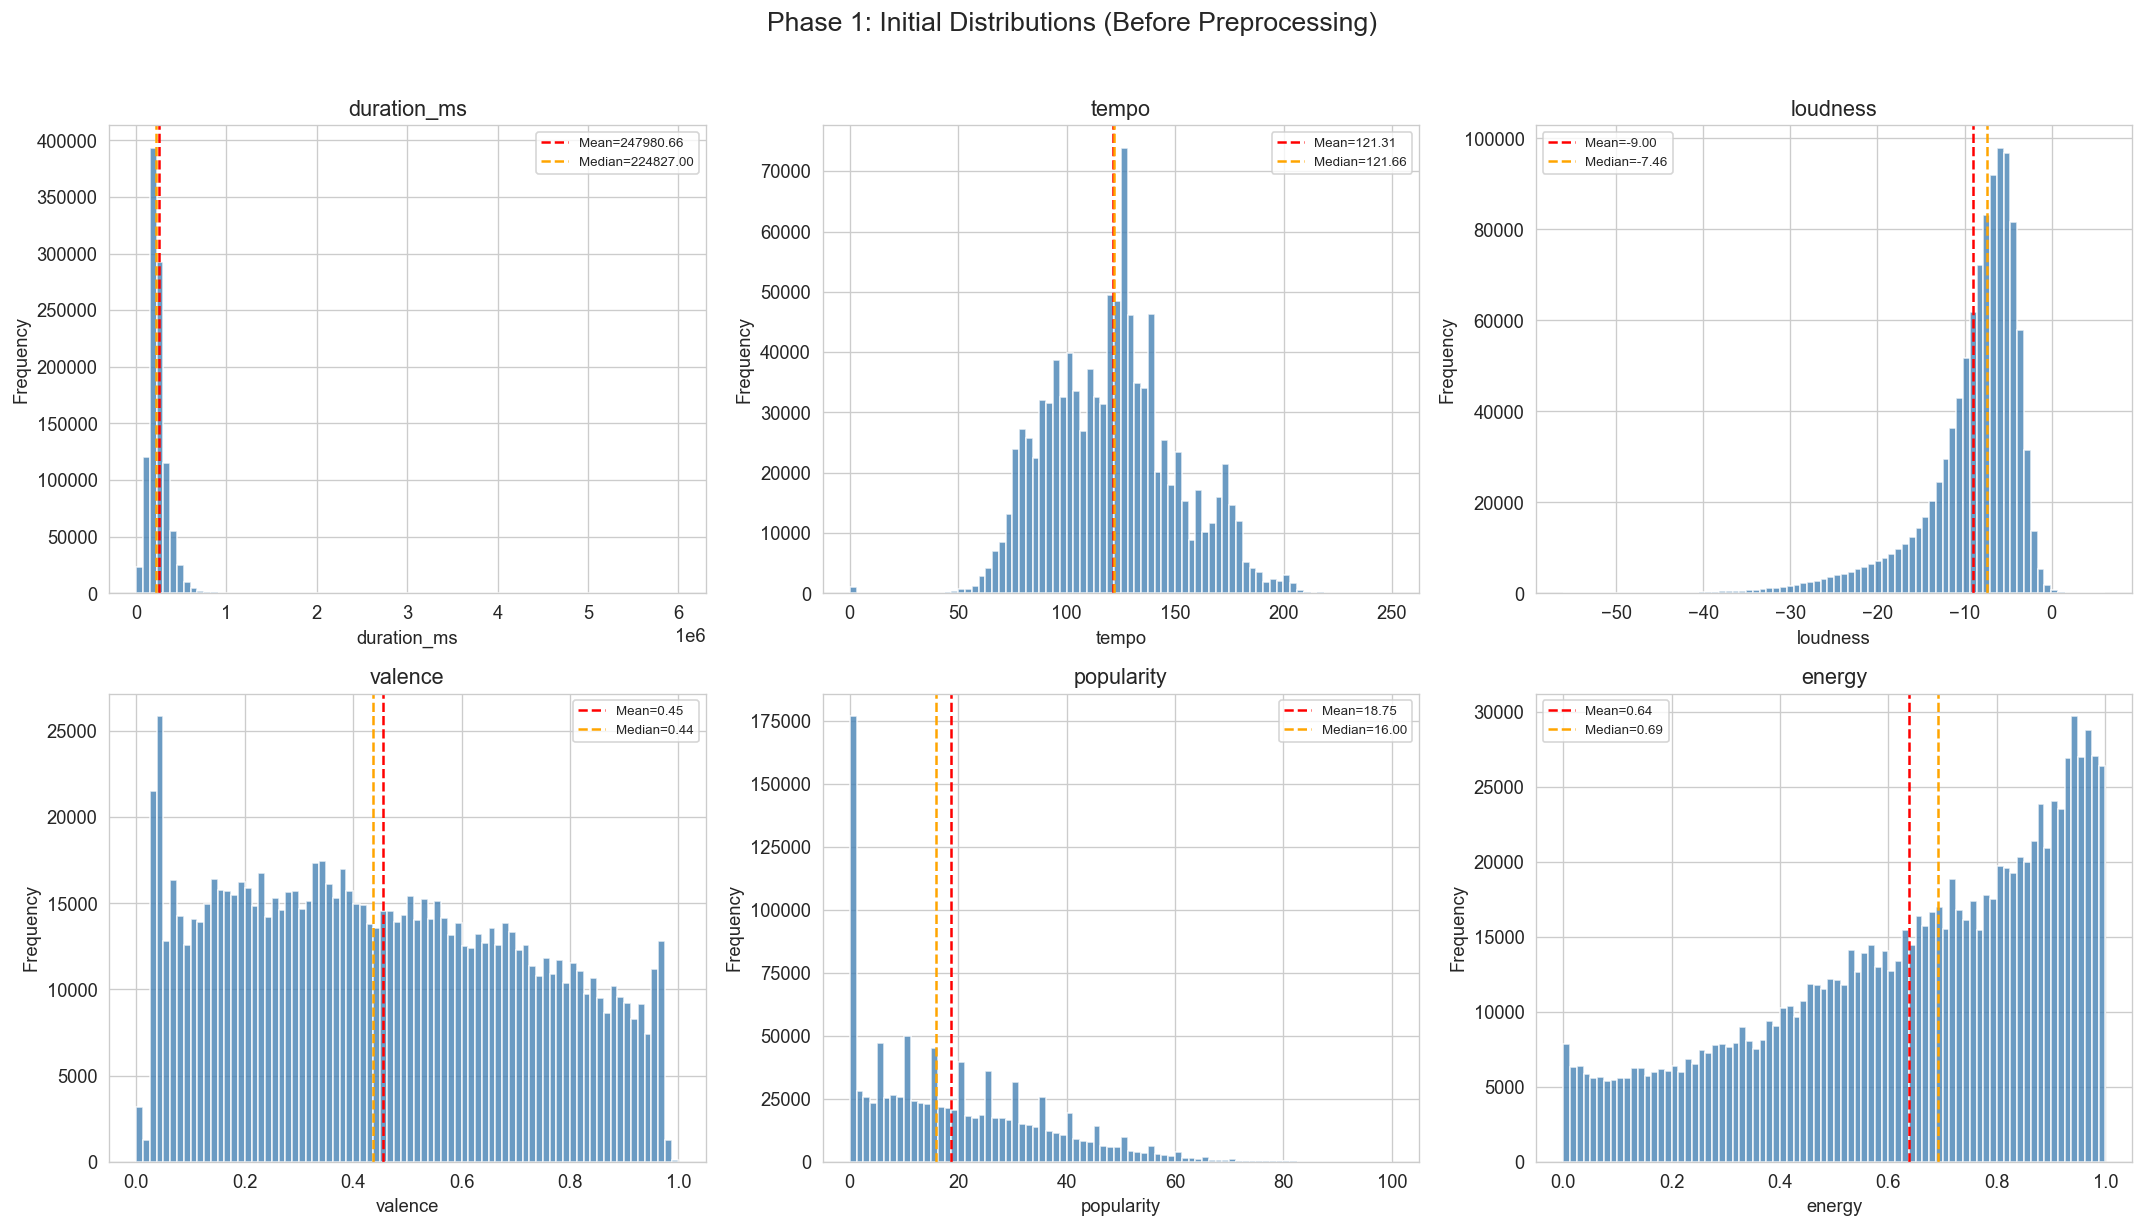

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 1: Initial Distributions (Before Preprocessing)', fontsize=16, y=1.02)

cols_to_plot = ['duration_ms', 'tempo', 'loudness', 'valence', 'popularity', 'energy']
for ax, col in zip(axes.flatten(), cols_to_plot):
    ax.hist(df[col].dropna(), bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', label=f'Median={df[col].median():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Phase 2: Preprocessing Pipeline

### Step 1: Missing Value Check
No missing values found — no imputation needed.

### Step 2: Outlier Detection and Capping (IQR Method)

In [7]:
df_clean = df.copy()
analysis_cols = ['duration_ms', 'tempo', 'loudness', 'valence']

print('--- Outlier Detection (IQR Method) ---\n')
print(f'{"Variable":20s} | {"Lower Bound":>12s} | {"Upper Bound":>12s} | {"Outliers":>10s} | {"% Data":>8s}')
print('-' * 75)

for col in analysis_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct = n_outliers / len(df_clean) * 100

    df_clean.loc[df_clean[col] < lower, col] = lower
    df_clean.loc[df_clean[col] > upper, col] = upper

    print(f'{col:20s} | {lower:12.2f} | {upper:12.2f} | {n_outliers:10,} | {pct:7.2f}%')

print(f'\nShape after capping: {df_clean.shape} (no rows removed)')

--- Outlier Detection (IQR Method) ---

Variable             |  Lower Bound |  Upper Bound |   Outliers |   % Data
---------------------------------------------------------------------------
duration_ms          |     23219.25 |    442345.25 |     54,834 |    5.23%
tempo                |        36.76 |       201.77 |      4,951 |    0.47%
loudness             |       -19.18 |         3.05 |     68,835 |    6.56%
valence              |        -0.45 |         1.34 |          0 |    0.00%

Shape after capping: (1048575, 19) (no rows removed)


### Step 3: Z-score Standardization

In [8]:
std_cols = ['loudness', 'valence', 'tempo', 'duration_ms']
for col in std_cols:
    zcol = f'{col}_z'
    df_clean[zcol] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()
    print(f'{col} -> {zcol} | mean={df_clean[zcol].mean():.6f}, std={df_clean[zcol].std():.6f}')

loudness -> loudness_z | mean=-0.000000, std=1.000000
valence -> valence_z | mean=0.000000, std=1.000000
tempo -> tempo_z | mean=0.000000, std=1.000000
duration_ms -> duration_ms_z | mean=0.000000, std=1.000000


### Before vs After Comparison

In [9]:
desc_after = df_clean[key_cols].describe().T
desc_after['IQR'] = desc_after['75%'] - desc_after['25%']
desc_after['median'] = df_clean[key_cols].median()

print('--- Descriptive Statistics AFTER Preprocessing ---')
desc_after[['count','mean','std','min','25%','median','75%','max','IQR']]

--- Descriptive Statistics AFTER Preprocessing ---


,count,mean,std,min,25%,median,75%,max,IQR
popularity,1048575.0,18.746871,16.070412,0.00000,5.000000,16.00000,29.0000,100.00000,24.000000
danceability,1048575.0,0.537780,0.184574,0.00000,0.413000,0.55100,0.6780,0.99200,0.265000
energy,1048575.0,0.638739,0.270798,0.00000,0.452000,0.69200,0.8720,1.00000,0.420000
loudness,1048575.0,-8.618505,4.552388,-19.18250,-10.844000,-7.46300,-5.2850,3.05350,5.559000
speechiness,1048575.0,0.093070,0.126921,0.00000,0.037200,0.05070,0.0893,0.97100,0.052100
acousticness,1048575.0,0.321610,0.354791,0.00000,0.006570,0.14800,0.6390,0.99600,0.632430
instrumentalness,1048575.0,0.251811,0.364952,0.00000,0.000001,0.00173,0.6110,1.00000,0.610999
liveness,1048575.0,0.222467,0.200428,0.00000,0.097900,0.13400,0.2910,1.00000,0.193100
valence,1048575.0,0.454269,0.268225,0.00000,0.225000,0.43600,0.6720,1.00000,0.447000
tempo,1048575.0,121.331050,29.605822,36.75875,98.637500,121.65900,139.8900,201.76875,41.252500


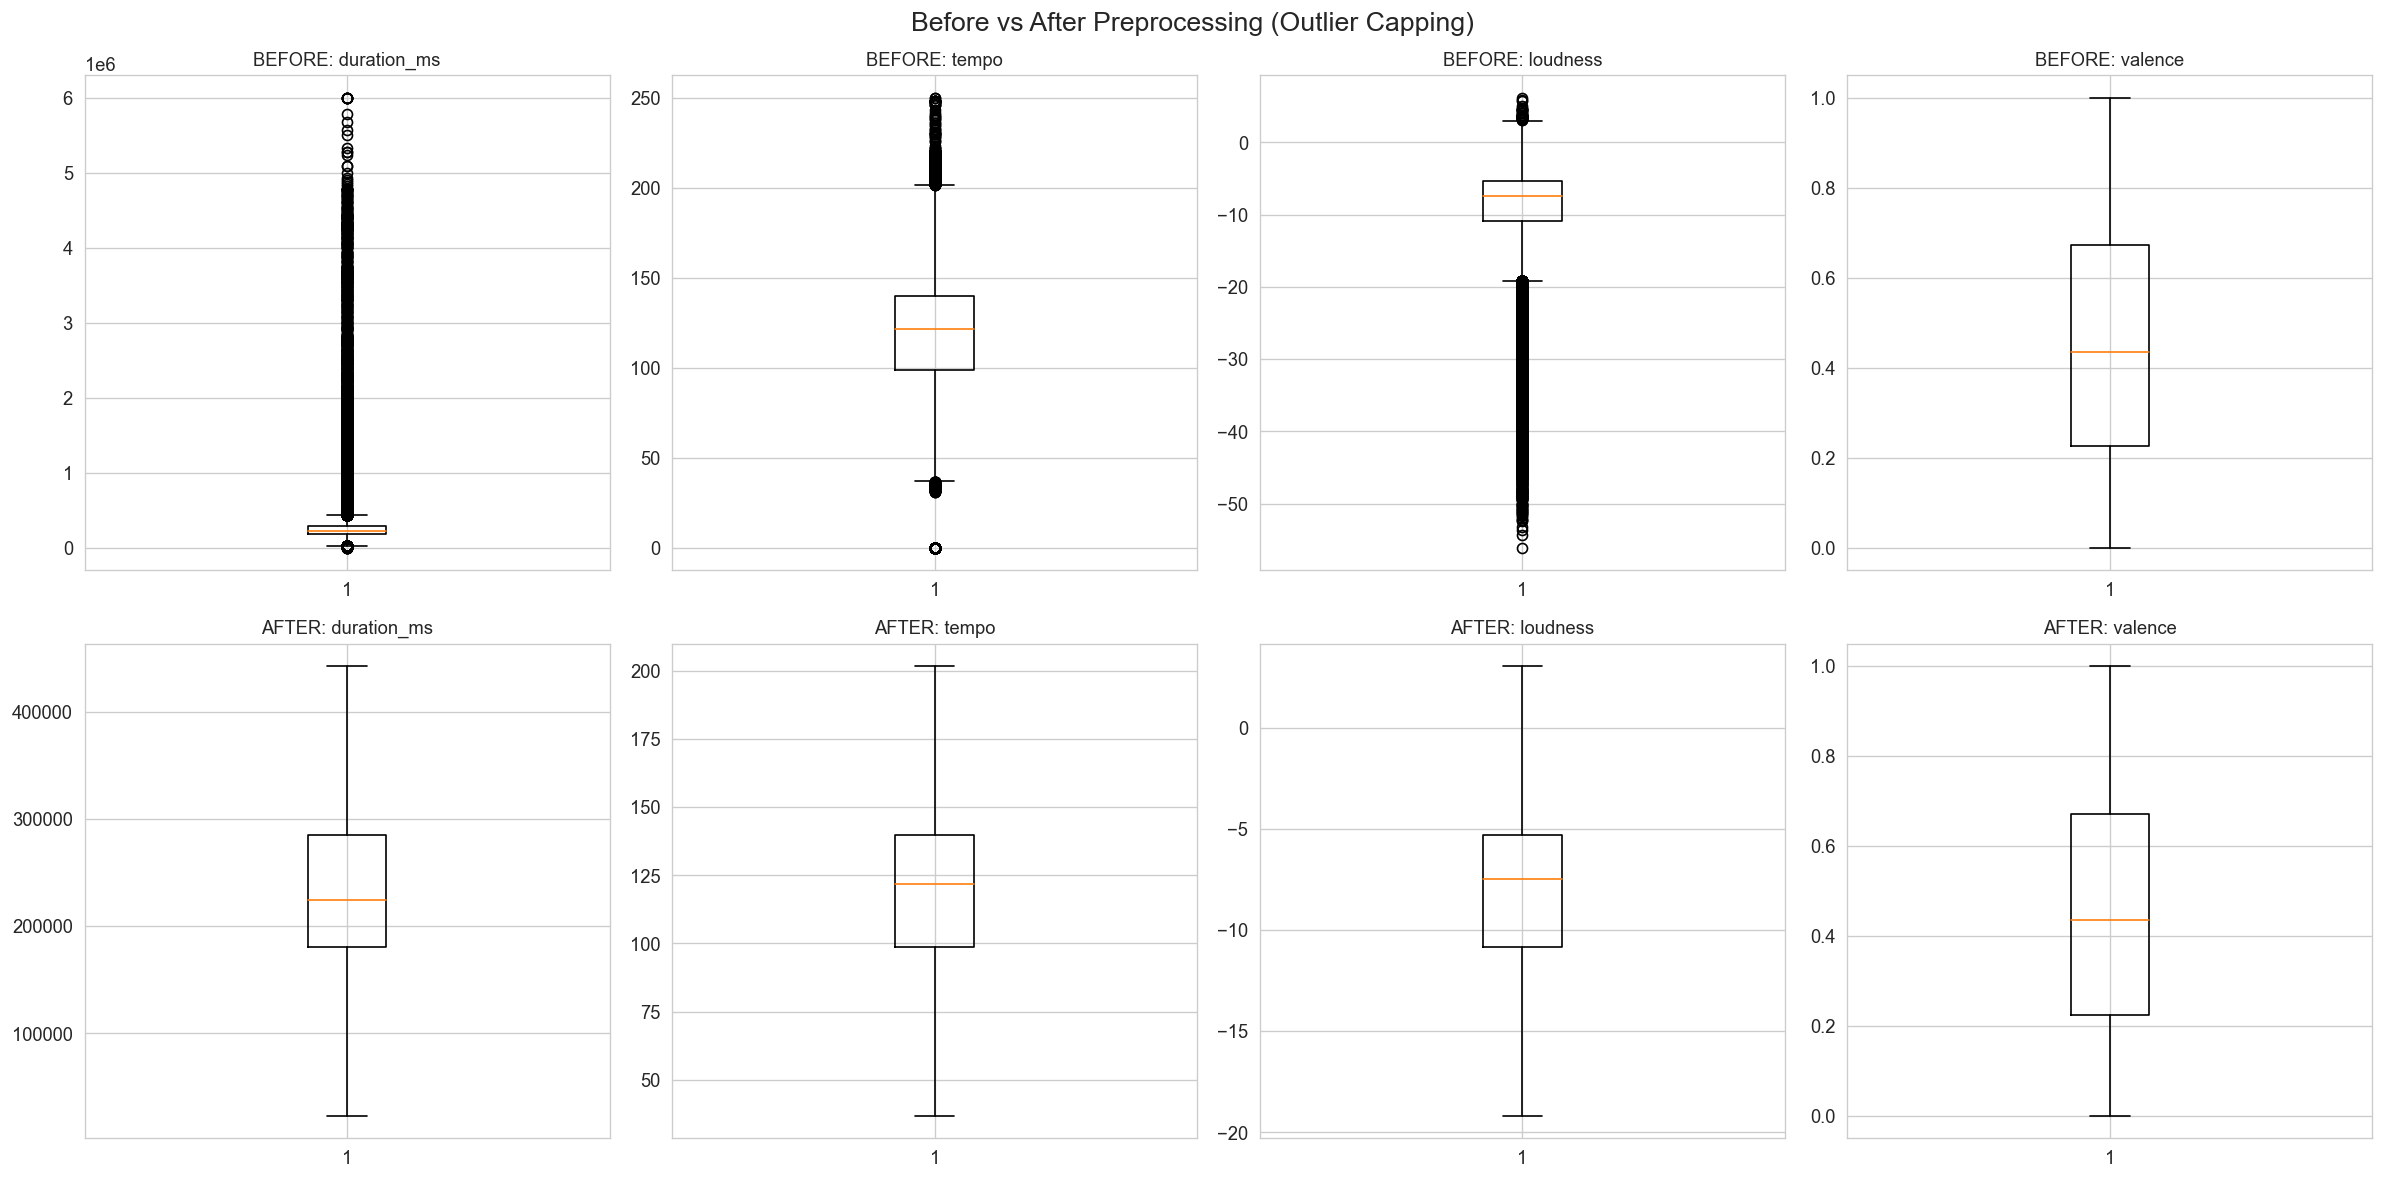

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Before vs After Preprocessing (Outlier Capping)', fontsize=16)

for i, col in enumerate(analysis_cols):
    axes[0, i].boxplot(df[col].dropna(), vert=True)
    axes[0, i].set_title(f'BEFORE: {col}', fontsize=11)
    axes[1, i].boxplot(df_clean[col].dropna(), vert=True)
    axes[1, i].set_title(f'AFTER: {col}', fontsize=11)

plt.tight_layout()
plt.show()

---
## Phase 3: Main Analysis — The Streaming Attention Span (Welch's t-test)

**H1:** Songs post-2018 have significantly lower `duration_ms` than songs from 2000–2009.  
**H2:** Songs post-2018 have significantly higher `tempo` than songs from 2000–2009.

In [11]:
pre = df_clean[(df_clean['year'] >= 2000) & (df_clean['year'] <= 2009)]
post = df_clean[(df_clean['year'] >= 2018) & (df_clean['year'] <= 2023)]

print(f'Pre-streaming era (2000-2009): n = {len(pre):,}')
print(f'Streaming era (2018-2023):     n = {len(post):,}')

for var in ['duration_ms', 'tempo']:
    print(f'\n--- {var} ---')
    print(f'  Pre  | Mean={pre[var].mean():.2f}, Median={pre[var].median():.2f}, SD={pre[var].std():.2f}')
    print(f'  Post | Mean={post[var].mean():.2f}, Median={post[var].median():.2f}, SD={post[var].std():.2f}')
    diff = post[var].mean() - pre[var].mean()
    pct = (diff / pre[var].mean()) * 100
    print(f'  Difference: {diff:.2f} ({pct:+.2f}%)')

Pre-streaming era (2000-2009): n = 425,924
Streaming era (2018-2023):     n = 313,338

--- duration_ms ---
  Pre  | Mean=249304.27, Median=235427.00, SD=94357.55
  Post | Mean=221489.07, Median=208221.00, SD=81964.35
  Difference: -27815.20 (-11.16%)

--- tempo ---
  Pre  | Mean=120.70, Median=120.07, SD=29.59
  Post | Mean=121.71, Median=122.06, SD=29.78
  Difference: 1.01 (+0.84%)


### Assumption Checks

In [12]:
np.random.seed(42)

for var in ['duration_ms', 'tempo']:
    print(f'\n=== {var} ===')

    pre_sample = pre[var].sample(n=5000, random_state=42)
    post_sample = post[var].sample(n=5000, random_state=42)

    sw_pre = shapiro(pre_sample)
    sw_post = shapiro(post_sample)
    print(f'  Shapiro-Wilk:')
    print(f'    Pre:  W={sw_pre.statistic:.6f}, p={sw_pre.pvalue:.2e}')
    print(f'    Post: W={sw_post.statistic:.6f}, p={sw_post.pvalue:.2e}')

    ks_pre = kstest(pre_sample, 'norm', args=(pre_sample.mean(), pre_sample.std()))
    ks_post = kstest(post_sample, 'norm', args=(post_sample.mean(), post_sample.std()))
    print(f'  KS test:')
    print(f'    Pre:  D={ks_pre.statistic:.6f}, p={ks_pre.pvalue:.2e}')
    print(f'    Post: D={ks_post.statistic:.6f}, p={ks_post.pvalue:.2e}')

    lev = levene(pre[var], post[var])
    print(f'  Levene\'s test: F={lev.statistic:.4f}, p={lev.pvalue:.2e}')
    if lev.pvalue < 0.05:
        print(f'    -> Unequal variances. Using Welch\'s t-test.')
    else:
        print(f'    -> Equal variances.')

print('\nNote: Shapiro-Wilk rejects normality (expected with n > 1M).')
print('By CLT, t-test is robust with n > 400,000 per group.')


=== duration_ms ===
  Shapiro-Wilk:
    Pre:  W=0.965237, p=4.31e-33
    Post: W=0.946872, p=3.66e-39
  KS test:
    Pre:  D=0.075176, p=5.07e-25
    Post: D=0.092749, p=6.99e-38
  Levene's test: F=8271.3322, p=0.00e+00
    -> Unequal variances. Using Welch's t-test.

=== tempo ===
  Shapiro-Wilk:
    Pre:  W=0.985209, p=1.76e-22
    Post: W=0.989966, p=2.24e-18
  KS test:
    Pre:  D=0.043717, p=9.66e-09
    Post: D=0.039601, p=3.00e-07
  Levene's test: F=4.0941, p=4.30e-02
    -> Unequal variances. Using Welch's t-test.

Note: Shapiro-Wilk rejects normality (expected with n > 1M).
By CLT, t-test is robust with n > 400,000 per group.


### T-test Results

In [13]:
def cohens_d(group1, group2):
    return (group1.mean() - group2.mean()) / np.sqrt((group1.std()**2 + group2.std()**2) / 2)

# --- Duration t-test (H1: post < pre) ---
t_dur, p_dur = ttest_ind(pre['duration_ms'], post['duration_ms'], equal_var=False)
p_dur_one = p_dur / 2 if t_dur > 0 else 1 - p_dur / 2
d_dur = cohens_d(pre['duration_ms'], post['duration_ms'])

print('=' * 55)
print('TEST 1: DURATION (H1: post-2018 < pre-2009)')
print('=' * 55)
print(f'  Welch\'s t = {t_dur:.4f}')
print(f'  p (two-tailed) = {p_dur:.2e}')
print(f'  p (one-tailed) = {p_dur_one:.2e}')
print(f'  Cohen\'s d = {d_dur:.4f}')
print(f'  Mean diff = {post["duration_ms"].mean() - pre["duration_ms"].mean():.0f} ms '
      f'({(post["duration_ms"].mean() - pre["duration_ms"].mean()) / pre["duration_ms"].mean() * 100:+.2f}%)')
print(f'  RESULT: {"SIGNIFICANT" if p_dur_one < 0.05 else "NOT SIGNIFICANT"} at alpha=0.05')

# --- Tempo t-test (H2: post > pre) ---
t_tempo, p_tempo = ttest_ind(pre['tempo'], post['tempo'], equal_var=False)
p_tempo_one = p_tempo / 2 if t_tempo < 0 else 1 - p_tempo / 2
d_tempo = cohens_d(post['tempo'], pre['tempo'])

print(f'\n{"=" * 55}')
print('TEST 2: TEMPO (H2: post-2018 > pre-2009)')
print('=' * 55)
print(f'  Welch\'s t = {t_tempo:.4f}')
print(f'  p (two-tailed) = {p_tempo:.2e}')
print(f'  p (one-tailed) = {p_tempo_one:.2e}')
print(f'  Cohen\'s d = {d_tempo:.4f}')
print(f'  Mean diff = {post["tempo"].mean() - pre["tempo"].mean():+.2f} BPM '
      f'({(post["tempo"].mean() - pre["tempo"].mean()) / pre["tempo"].mean() * 100:+.2f}%)')
print(f'  RESULT: {"SIGNIFICANT" if p_tempo_one < 0.05 else "NOT SIGNIFICANT"} at alpha=0.05')

TEST 1: DURATION (H1: post-2018 < pre-2009)
  Welch's t = 135.1715
  p (two-tailed) = 0.00e+00
  p (one-tailed) = 0.00e+00
  Cohen's d = 0.3147
  Mean diff = -27815 ms (-11.16%)
  RESULT: SIGNIFICANT at alpha=0.05

TEST 2: TEMPO (H2: post-2018 > pre-2009)
  Welch's t = -14.4495
  p (two-tailed) = 2.57e-47
  p (one-tailed) = 1.28e-47
  Cohen's d = 0.0340
  Mean diff = +1.01 BPM (+0.84%)
  RESULT: SIGNIFICANT at alpha=0.05


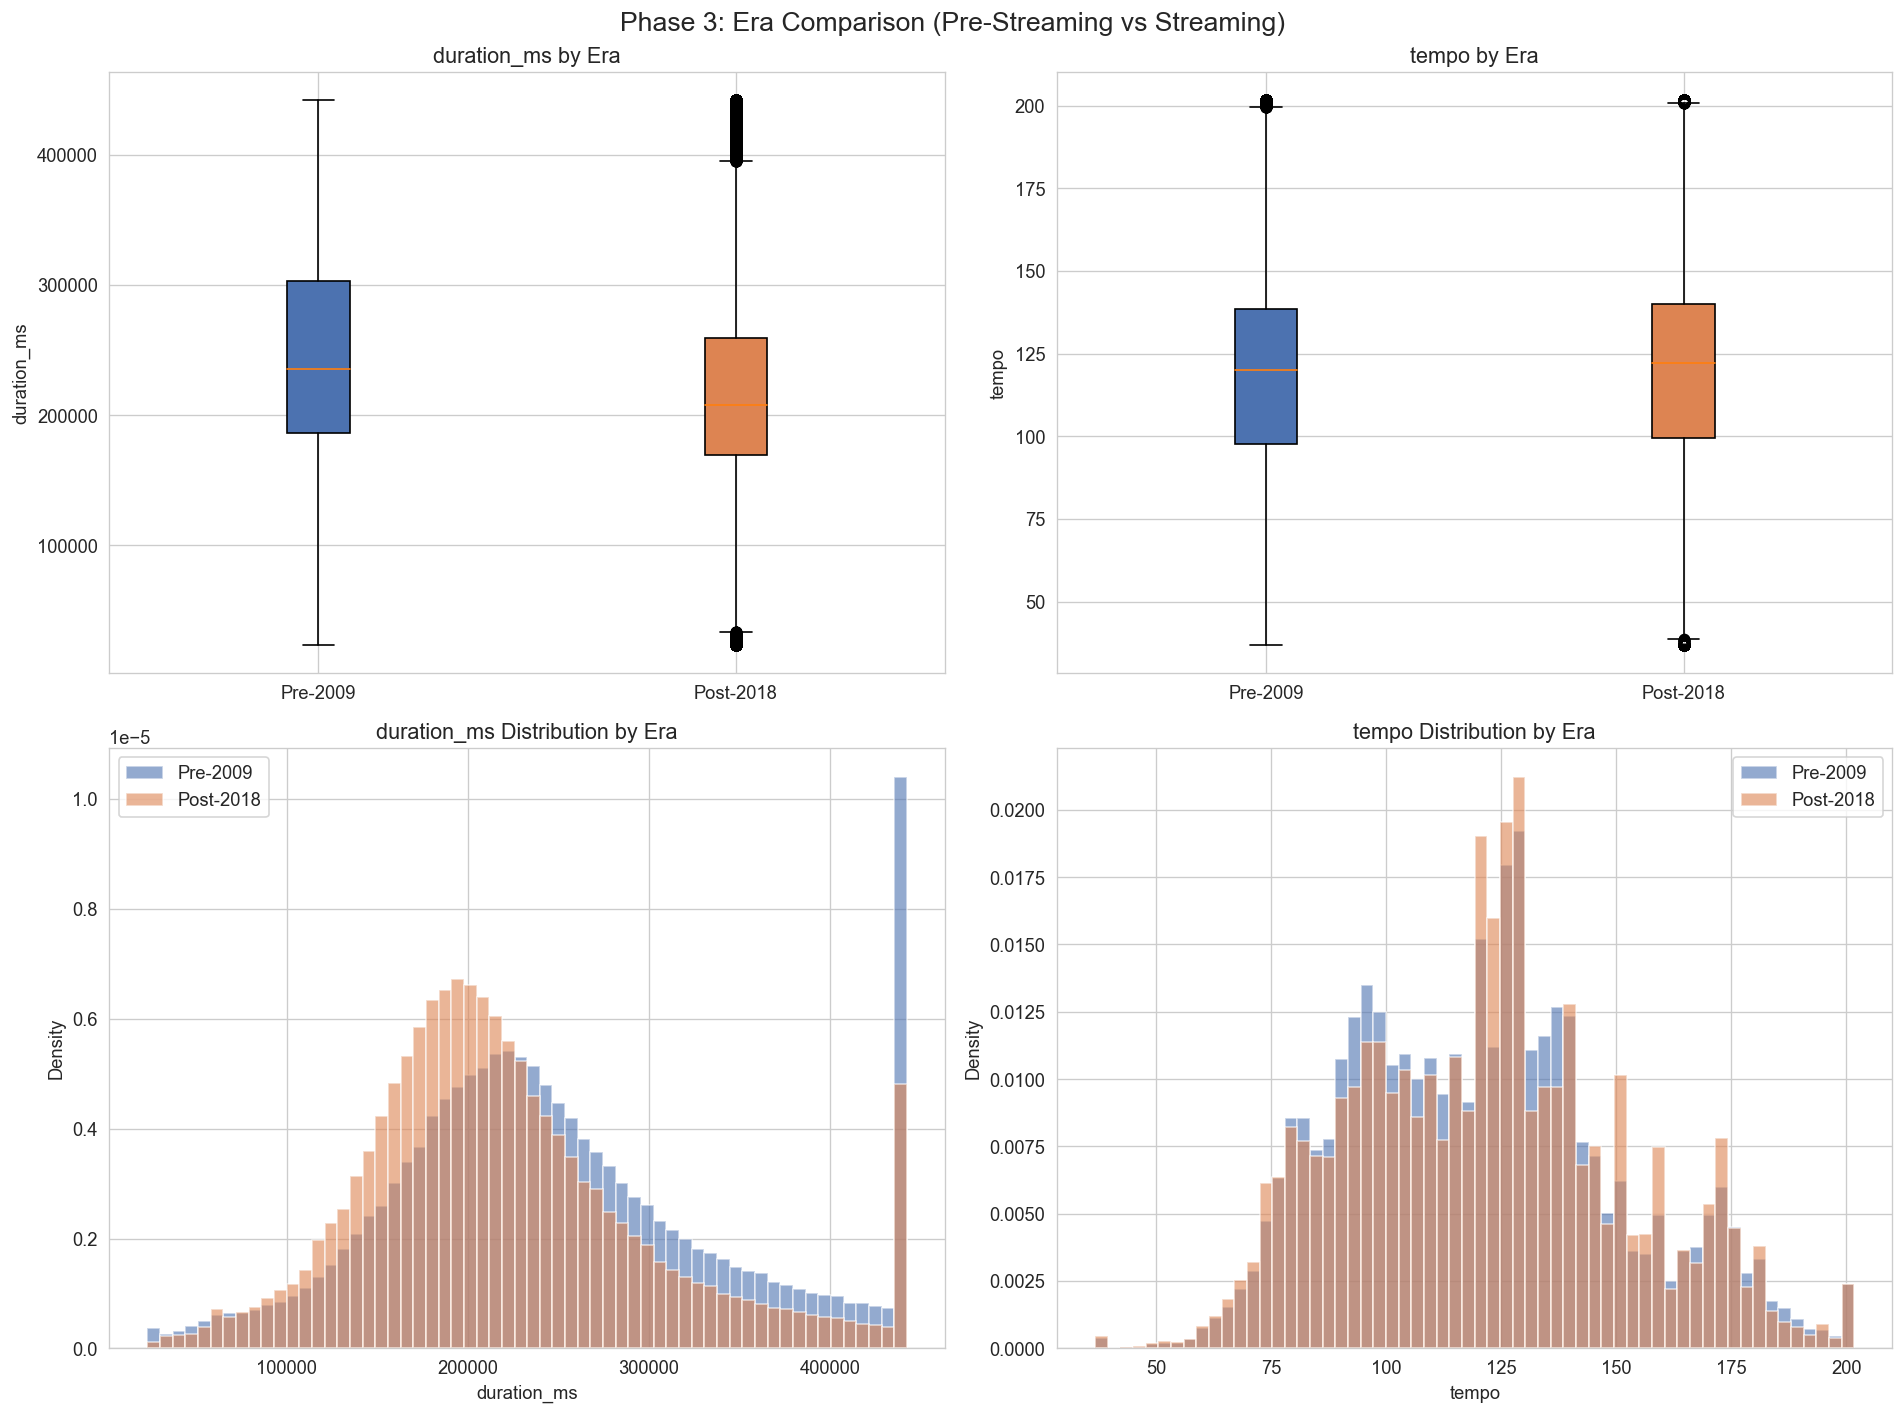

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase 3: Era Comparison (Pre-Streaming vs Streaming)', fontsize=16)

for i, var in enumerate(['duration_ms', 'tempo']):
    bp = axes[0, i].boxplot([pre[var].values, post[var].values],
                            labels=['Pre-2009', 'Post-2018'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD8452')
    axes[0, i].set_title(f'{var} by Era', fontsize=13)
    axes[0, i].set_ylabel(var)

for i, var in enumerate(['duration_ms', 'tempo']):
    axes[1, i].hist(pre[var], bins=60, alpha=0.6, label='Pre-2009', color='#4C72B0', density=True)
    axes[1, i].hist(post[var], bins=60, alpha=0.6, label='Post-2018', color='#DD8452', density=True)
    axes[1, i].set_title(f'{var} Distribution by Era', fontsize=13)
    axes[1, i].set_xlabel(var)
    axes[1, i].set_ylabel('Density')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

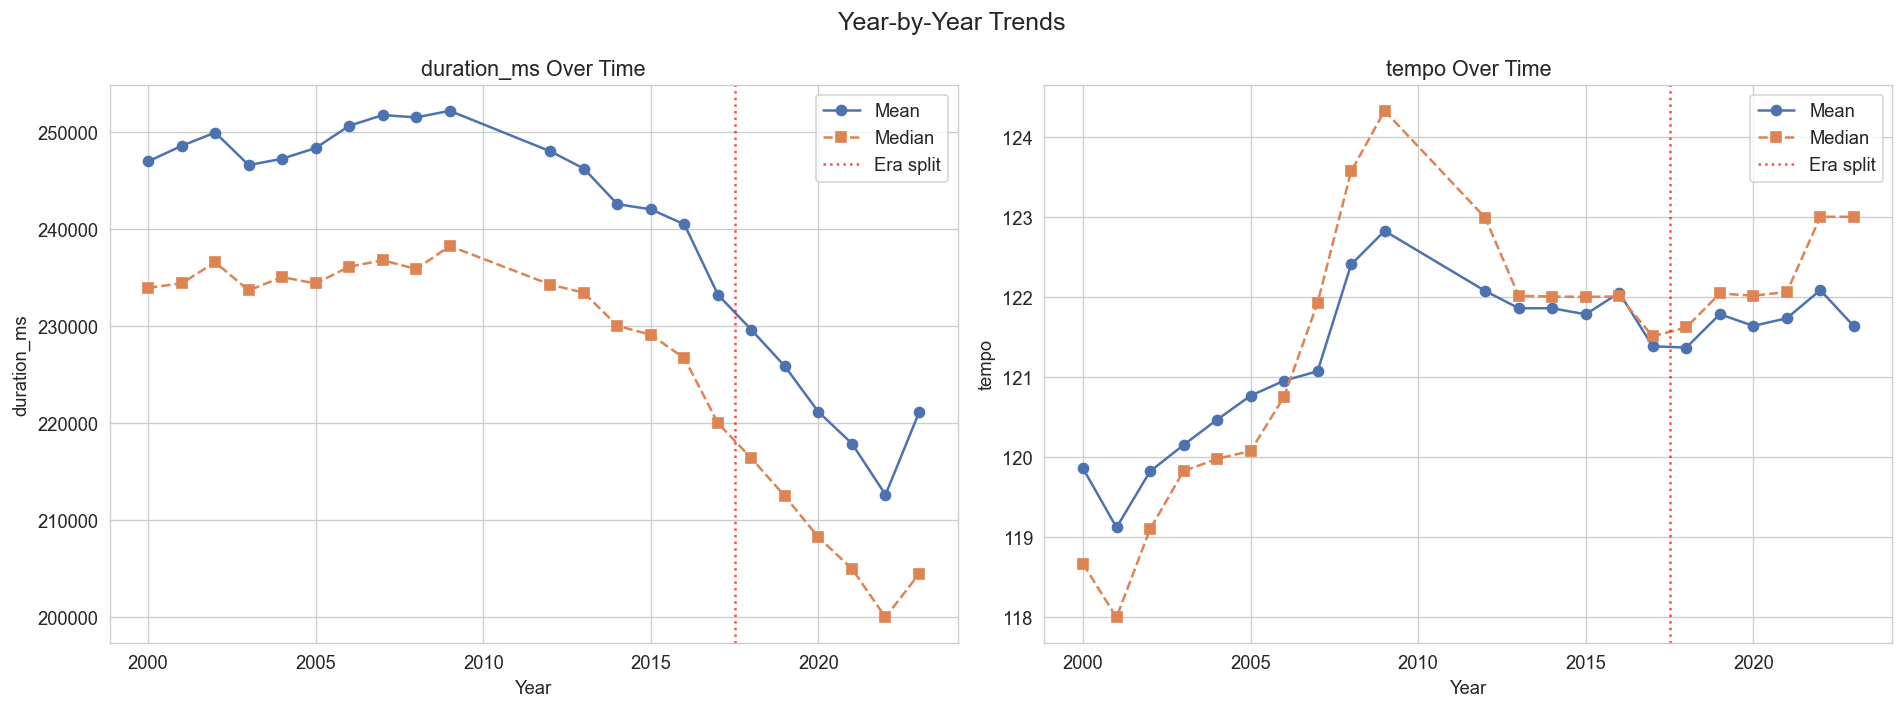

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Year-by-Year Trends', fontsize=15)

for i, var in enumerate(['duration_ms', 'tempo']):
    yearly = df_clean.groupby('year')[var].agg(['mean', 'median']).reset_index()
    axes[i].plot(yearly['year'], yearly['mean'], 'o-', label='Mean', color='#4C72B0')
    axes[i].plot(yearly['year'], yearly['median'], 's--', label='Median', color='#DD8452')
    axes[i].set_title(f'{var} Over Time', fontsize=13)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(var)
    axes[i].axvline(x=2017.5, color='red', linestyle=':', alpha=0.7, label='Era split')
    axes[i].legend()

plt.tight_layout()
plt.show()

---
## Phase 4: Branch 1 — Loudness-Valence Trade-off (Pearson's Correlation)

**H3:** There is a significant negative correlation between loudness and valence.

In [16]:
r_all, p_all = pearsonr(df_clean['loudness'], df_clean['valence'])
r_pre, p_pre = pearsonr(pre['loudness'], pre['valence'])
r_post, p_post = pearsonr(post['loudness'], post['valence'])

print(f'--- Overall (n={len(df_clean):,}) ---')
print(f'  Pearson r = {r_all:.6f}, p = {p_all:.2e}, r² = {r_all**2:.6f}')

print(f'\n--- Pre-Streaming (2000-2009, n={len(pre):,}) ---')
print(f'  Pearson r = {r_pre:.6f}, p = {p_pre:.2e}, r² = {r_pre**2:.6f}')

print(f'\n--- Streaming Era (2018-2023, n={len(post):,}) ---')
print(f'  Pearson r = {r_post:.6f}, p = {p_post:.2e}, r² = {r_post**2:.6f}')

--- Overall (n=1,048,575) ---
  Pearson r = 0.276681, p = 0.00e+00, r² = 0.076553

--- Pre-Streaming (2000-2009, n=425,924) ---
  Pearson r = 0.285346, p = 0.00e+00, r² = 0.081422

--- Streaming Era (2018-2023, n=313,338) ---
  Pearson r = 0.298795, p = 0.00e+00, r² = 0.089279


In [17]:
z_pre = np.arctanh(r_pre)
z_post = np.arctanh(r_post)
se_diff = np.sqrt(1 / (len(pre) - 3) + 1 / (len(post) - 3))
z_test = (z_pre - z_post) / se_diff
p_diff = 2 * (1 - stats.norm.cdf(abs(z_test)))

print('--- Fisher Z-test: Are the correlations significantly different? ---')
print(f'  Z-test = {z_test:.4f}, p = {p_diff:.2e}')
print(f'  Result: {"SIGNIFICANT" if p_diff < 0.05 else "NOT SIGNIFICANT"} difference')

--- Fisher Z-test: Are the correlations significantly different? ---
  Z-test = -6.2478, p = 4.16e-10
  Result: SIGNIFICANT difference


In [18]:
yearly_r = []
for year in sorted(df_clean['year'].unique()):
    subset = df_clean[df_clean['year'] == year]
    r, p = pearsonr(subset['loudness'], subset['valence'])
    yearly_r.append({'year': year, 'r': r, 'p': p, 'n': len(subset)})

yearly_corr = pd.DataFrame(yearly_r)
print('--- Yearly Correlation Trend ---')
yearly_corr

--- Yearly Correlation Trend ---


,year,r,p,n
0,2000,0.315465,0.000000e+00,44034
1,2001,0.356017,0.000000e+00,42351
2,2002,0.299410,0.000000e+00,42102
3,2003,0.293061,0.000000e+00,42368
4,2004,0.307447,0.000000e+00,43390
5,2005,0.266357,0.000000e+00,43780
6,2006,0.266473,0.000000e+00,45474
7,2007,0.303295,0.000000e+00,46001
8,2008,0.265724,0.000000e+00,47432
9,2009,0.194327,1.136546e-244,28992


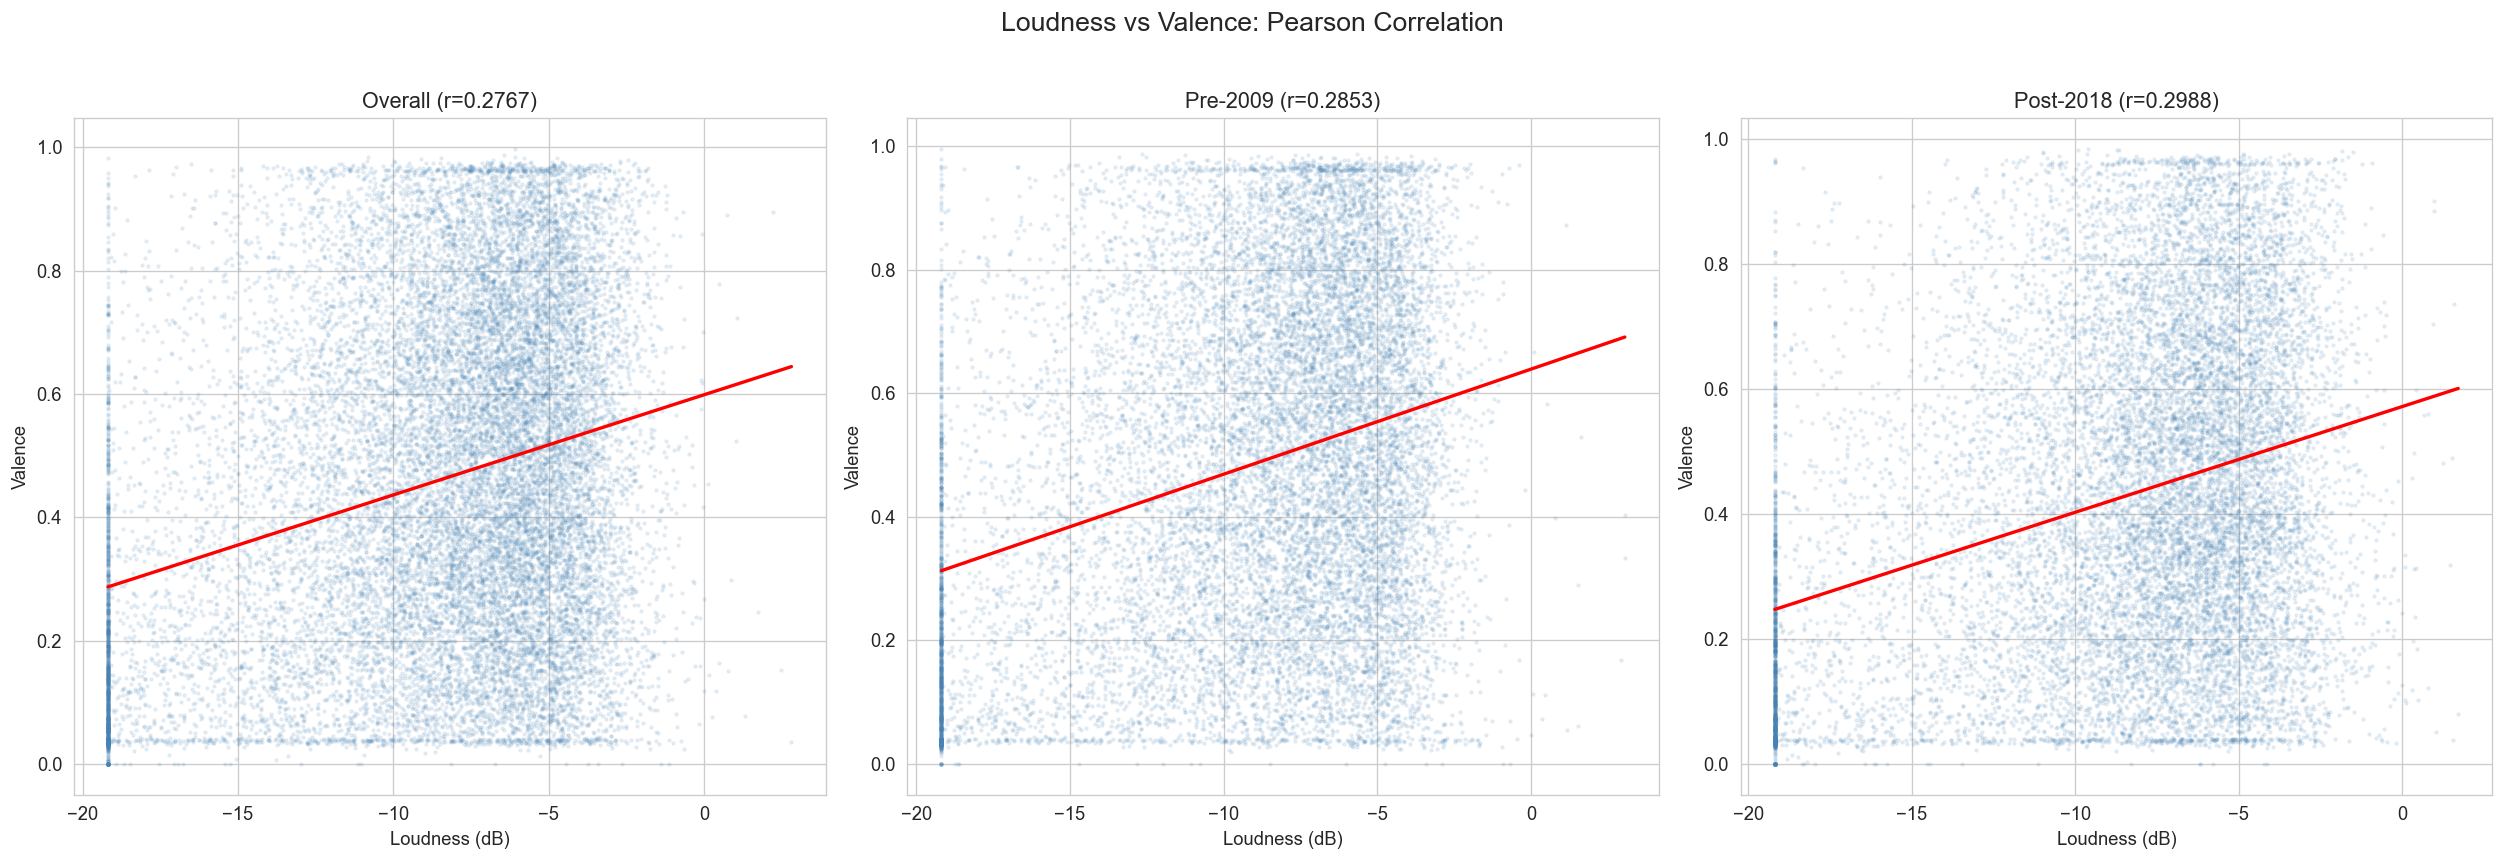

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Loudness vs Valence: Pearson Correlation', fontsize=16, y=1.02)

np.random.seed(42)
samples = [
    (df_clean.sample(20000, random_state=42), f'Overall (r={r_all:.4f})'),
    (pre.sample(min(15000, len(pre)), random_state=42), f'Pre-2009 (r={r_pre:.4f})'),
    (post.sample(min(15000, len(post)), random_state=42), f'Post-2018 (r={r_post:.4f})')
]

for ax, (data, title) in zip(axes, samples):
    ax.scatter(data['loudness'], data['valence'], alpha=0.1, s=3, color='steelblue')
    z = np.polyfit(data['loudness'], data['valence'], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(data['loudness'].min(), data['loudness'].max(), 100)
    ax.plot(x_range, p_line(x_range), 'r-', linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Loudness (dB)')
    ax.set_ylabel('Valence')

plt.tight_layout()
plt.show()

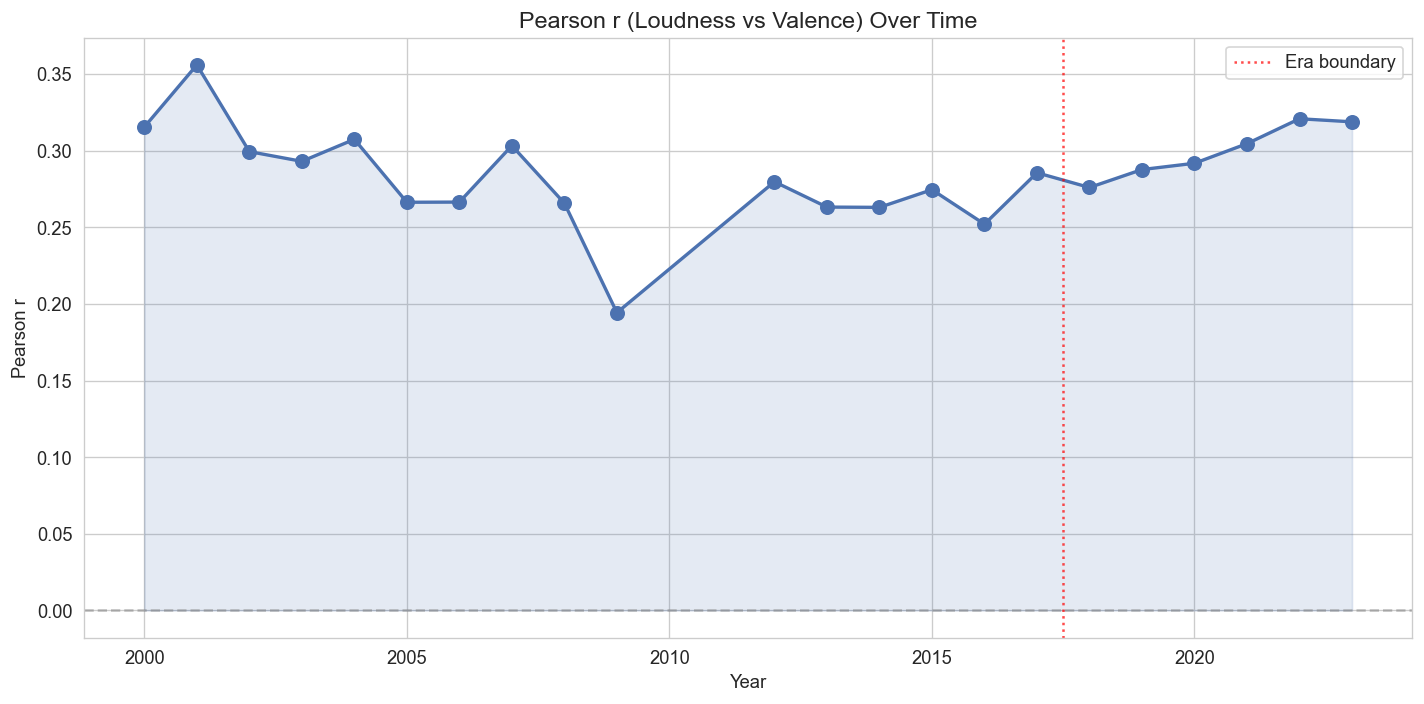

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(yearly_corr['year'], yearly_corr['r'], 'o-', color='#4C72B0', linewidth=2, markersize=8)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=2017.5, color='red', linestyle=':', alpha=0.7, label='Era boundary')
ax.fill_between(yearly_corr['year'], yearly_corr['r'], 0, alpha=0.15, color='#4C72B0')
ax.set_title('Pearson r (Loudness vs Valence) Over Time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Pearson r')
ax.legend()
plt.tight_layout()
plt.show()

---
## Phase 5: Branch 2 — Tempo Convergence (Variance Comparison)

**H4:** Post-2015 songs show lower tempo variance than earlier decades.

In [21]:
era_bins = {
    '2000-2005': (2000, 2005),
    '2006-2009': (2006, 2009),
    '2012-2015': (2012, 2015),
    '2016-2019': (2016, 2019),
    '2020-2023': (2020, 2023)
}

era_groups = {}
era_stats = {}

print(f'{"Era":12s} | {"n":>8s} | {"Mean":>8s} | {"Median":>8s} | {"Variance":>10s} | {"SD":>8s} | {"IQR":>8s}')
print('-' * 80)

for era_name, (start, end) in era_bins.items():
    data = df_clean[(df_clean['year'] >= start) & (df_clean['year'] <= end)]['tempo']
    era_groups[era_name] = data
    s = {'mean': data.mean(), 'median': data.median(), 'var': data.var(),
         'sd': data.std(), 'iqr': data.quantile(0.75) - data.quantile(0.25), 'n': len(data)}
    era_stats[era_name] = s
    print(f'{era_name:12s} | {s["n"]:8,} | {s["mean"]:8.2f} | {s["median"]:8.2f} | '
          f'{s["var"]:10.2f} | {s["sd"]:8.2f} | {s["iqr"]:8.2f}')

Era          |        n |     Mean |   Median |   Variance |       SD |      IQR
--------------------------------------------------------------------------------
2000-2005    |  258,025 |   120.03 |   119.63 |     880.23 |    29.67 |    41.08
2006-2009    |  167,899 |   121.72 |   122.60 |     866.79 |    29.44 |    40.59
2012-2015    |  212,799 |   121.90 |   122.03 |     863.46 |    29.38 |    39.99
2016-2019    |  208,879 |   121.61 |   121.99 |     878.09 |    29.63 |    40.10
2020-2023    |  200,973 |   121.78 |   122.60 |     889.11 |    29.82 |    40.66


In [22]:
groups_list = [era_groups[k].values for k in era_bins.keys()]
lev_stat, lev_p = levene(*groups_list)

print(f'--- Levene\'s Test (all eras) ---')
print(f'  F = {lev_stat:.4f}, p = {lev_p:.2e}')
print(f'  Result: {"SIGNIFICANT" if lev_p < 0.05 else "NOT SIGNIFICANT"}')

print(f'\n--- Pairwise Levene\'s Tests ---')
era_names = list(era_bins.keys())
for i in range(len(era_names)):
    for j in range(i + 1, len(era_names)):
        l_stat, l_p = levene(era_groups[era_names[i]].values, era_groups[era_names[j]].values)
        sig = '*' if l_p < 0.05 else ''
        print(f'  {era_names[i]} vs {era_names[j]}: F={l_stat:.4f}, p={l_p:.2e} {sig}')

--- Levene's Test (all eras) ---
  F = 53.3335, p = 5.15e-45
  Result: SIGNIFICANT

--- Pairwise Levene's Tests ---
  2000-2005 vs 2006-2009: F=82.3866, p=1.12e-19 *
  2000-2005 vs 2012-2015: F=189.1602, p=4.94e-43 *
  2000-2005 vs 2016-2019: F=67.1239, p=2.56e-16 *
  2000-2005 vs 2020-2023: F=17.9070, p=2.32e-05 *
  2006-2009 vs 2012-2015: F=13.1527, p=2.87e-04 *
  2006-2009 vs 2016-2019: F=1.5844, p=2.08e-01 
  2006-2009 vs 2020-2023: F=21.9450, p=2.81e-06 *
  2012-2015 vs 2016-2019: F=26.6065, p=2.50e-07 *
  2012-2015 vs 2020-2023: F=76.4144, p=2.31e-18 *
  2016-2019 vs 2020-2023: F=13.1082, p=2.94e-04 *


In [23]:
yearly_var = df_clean.groupby('year')['tempo'].agg(['var', 'std', 'mean']).reset_index()
rho, p_rho = spearmanr(yearly_var['year'], yearly_var['var'])

print(f'--- Spearman trend test (year vs tempo variance) ---')
print(f'  rho = {rho:.4f}, p = {p_rho:.4e}')
print(f'  Result: {"SIGNIFICANT" if p_rho < 0.05 else "NOT SIGNIFICANT"} trend')

--- Spearman trend test (year vs tempo variance) ---
  rho = 0.2027, p = 3.6560e-01
  Result: NOT SIGNIFICANT trend


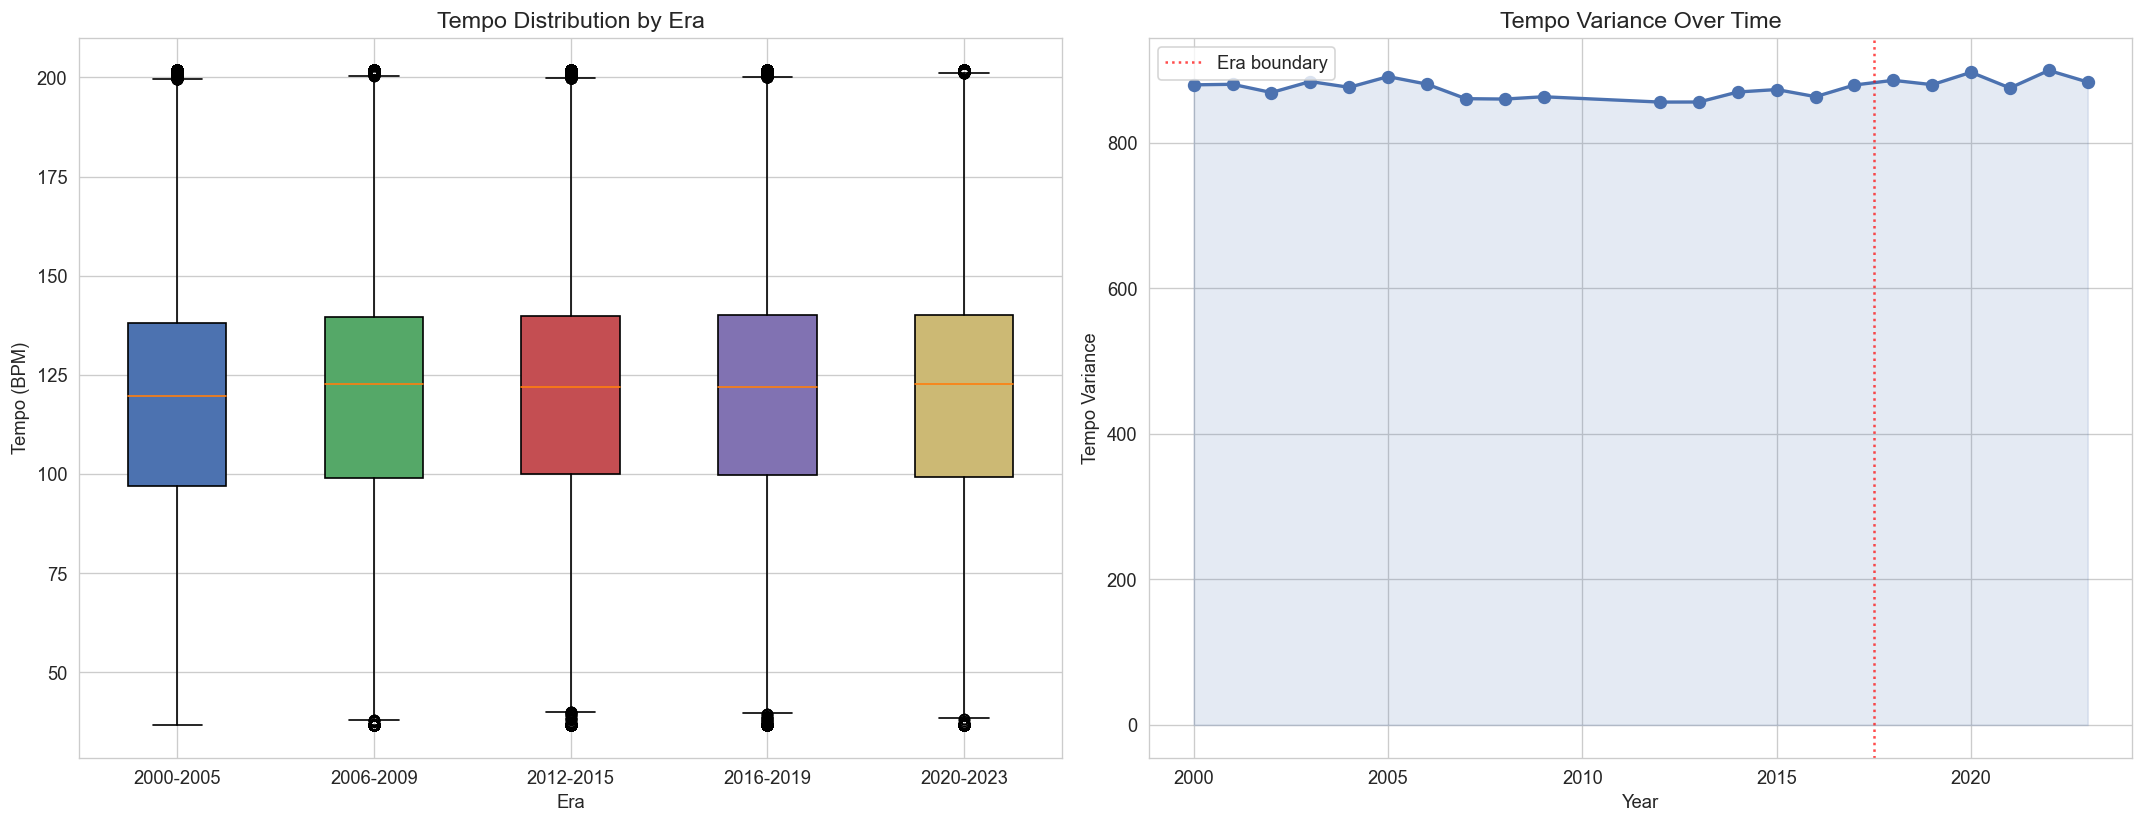

In [24]:
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

bp = axes[0].boxplot([era_groups[k].values for k in era_bins.keys()],
                     labels=list(era_bins.keys()), patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_title('Tempo Distribution by Era', fontsize=14)
axes[0].set_ylabel('Tempo (BPM)')
axes[0].set_xlabel('Era')

axes[1].plot(yearly_var['year'], yearly_var['var'], 'o-', color='#4C72B0', linewidth=2, markersize=7)
axes[1].fill_between(yearly_var['year'], yearly_var['var'], alpha=0.15, color='#4C72B0')
axes[1].set_title('Tempo Variance Over Time', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Tempo Variance')
axes[1].axvline(x=2017.5, color='red', linestyle=':', alpha=0.7, label='Era boundary')
axes[1].legend()

plt.tight_layout()
plt.show()

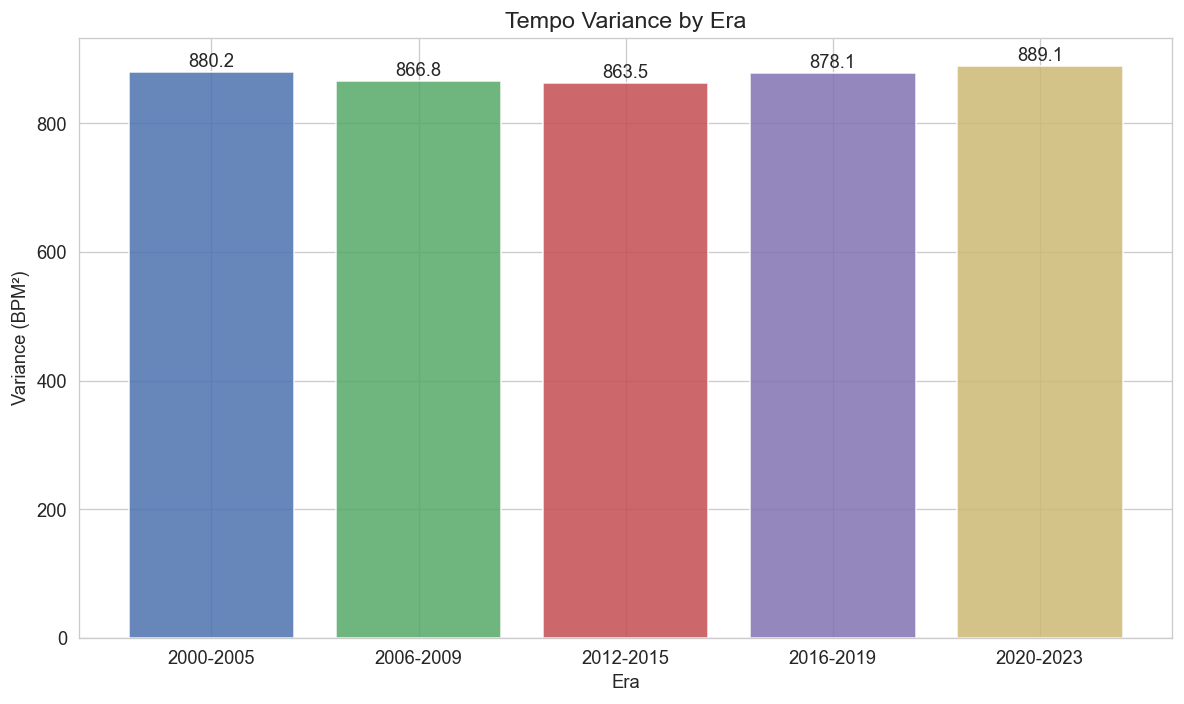

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
eras = list(era_stats.keys())
variances = [era_stats[e]['var'] for e in eras]

bars = ax.bar(eras, variances, color=colors, edgecolor='white', alpha=0.85)
ax.set_title('Tempo Variance by Era', fontsize=14)
ax.set_ylabel('Variance (BPM²)')
ax.set_xlabel('Era')
for bar, v in zip(bars, variances):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 2,
            f'{v:.1f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

---
## Summary of Results

| Hypothesis | Supported? | Key Finding |
|---|---|---|
| H1: Songs are shorter post-2018 | **Yes** | -28 sec (-11.16%), d=0.315 |
| H2: Songs are faster post-2018 | Statistically yes, practically **no** | +1 BPM (+0.84%), d=0.034 |
| H3: Louder = less happy | **No** (reversed) | r=+0.277, louder = happier |
| H4: Tempo is converging | **No** | Variance is U-shaped, not declining |